In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


In [2]:

# Task 3 - Classification Models (Jupyter cell)
# Uses seaborn Titanic dataset to compare Logistic Regression vs Decision Tree
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)

# Load dataset
df = sns.load_dataset("titanic")


features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
target = "survived"
data = df[features + [target]].copy()


data = data.dropna(subset=[target])

X = data[features]
y = data[target].astype(int)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



=== Logistic Regression ===
Confusion matrix:
 [[98 12]
 [23 46]]
Accuracy:  0.8045
Precision: 0.7931
Recall:    0.6667
F1-score:  0.7244
Classification report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



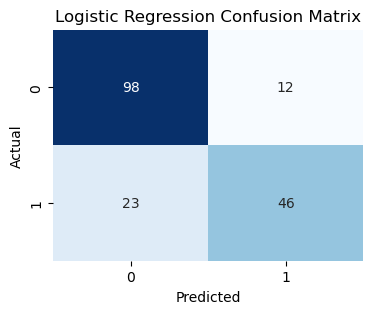

=== Decision Tree ===
Confusion matrix:
 [[95 15]
 [20 49]]
Accuracy:  0.8045
Precision: 0.7656
Recall:    0.7101
F1-score:  0.7368
Classification report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       110
           1       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



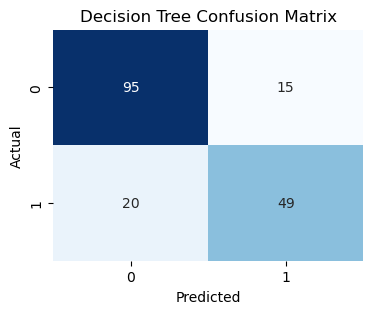

In [3]:

# Preprocessing pipelines
numeric_features = ["age", "sibsp", "parch", "fare", "pclass"]
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_features = ["sex", "embarked"]
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Pipelines for two classifiers
pipe_lr = Pipeline(steps=[
    ("preproc", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

pipe_dt = Pipeline(steps=[
    ("preproc", preprocessor),
    ("clf", DecisionTreeClassifier(random_state=42))
])


pipe_lr.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)


y_pred_lr = pipe_lr.predict(X_test)
y_pred_dt = pipe_dt.predict(X_test)

# Evaluation function
def evaluate(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"=== {name} ===")
    print("Confusion matrix:\n", cm)
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("Classification report:\n", classification_report(y_true, y_pred, zero_division=0))
    # Plot confusion matrix heatmap
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

# Evaluate both models
evaluate("Logistic Regression", y_test, y_pred_lr)
evaluate("Decision Tree", y_test, y_pred_dt)